# Is Road Accident Risk Socially and Spatially Unequal Across England? A Multi-Method Analysis of Deprivation, Urbanicity, and Casualty Severity

## Preparation

- [Github link](https://github.com/jie420/casa0006-road-inequality)

- Number of words: 1479

- Runtime: 2.4 minutes (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **geopandas**: Geospatial data manipulation and choropleth mapping.
    - **libpysal**: Spatial weights matrix construction (Queen contiguity).
    - **esda**: Moran's I spatial autocorrelation test.
    - **shap**: SHAP values for random forest interpretability.

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Road traffic casualties are among the most preventable causes of serious injury in England, yet their spatial and social distribution remains poorly understood. Research has shown that residents of more deprived areas face disproportionately higher risks of serious road accidents (Lyons et al., 2008; Graham & Glaister, 2003). Rural areas feature higher speed limits associated with more severe collisions, while urban areas face greater pedestrian exposure (Department for Transport, 2023). Random forest regression with SHAP values can reveal non-linear effects that conventional regression obscures (Lundberg & Lee, 2017), while Moran's I situates findings geographically (Anselin, 1995).

This study uses five years of STATS19 road casualty data (2020–2024), linked to IMD 2025 and ONS population estimates, to examine whether road accident risk is socially and spatially unequal across England's Local Authority Districts (LADs) using four analytical methods applied in sequence.

## Research questions

[[ go back to the top ]](#Table-of-contents)

**RQ1:** Is the rate of serious (killed or seriously injured) road casualties spatially clustered across Local Authority Districts in England, and if so, where are the highest-risk areas concentrated?

**RQ2:** To what extent do area-level social deprivation, urbanicity, and mean road speed limit explain variation in serious casualty rates across English LADs?

**RQ3:** What are the most important features — across both social deprivation domains and structural road characteristics — for predicting serious casualty rates, and do they operate non-linearly?

**RQ4:** Can English LADs be meaningfully classified into distinct spatial risk profiles based on their combination of casualty rate, deprivation, urbanicity, and speed characteristics, and what policy implications do these profiles carry?

## Data

[[ go back to the top ]](#Table-of-contents)

This study uses four datasets, all loaded remotely from the project GitHub repository:

| Dataset | Source | Geography | Key variables used |
|---------|--------|-----------|--------------------|
| STATS19 Road Casualty Statistics (2020–2024) | UK Department for Transport, data.gov.uk | Collision-level (with LSOA/LAD codes) | `collision_severity`, `local_authority_ons_district`, `urban_or_rural_area`, `casualty_severity`, `casualty_imd_decile` |
| Index of Multiple Deprivation 2025 (LAD summary) | MHCLG, opendatacommunities.org | Local Authority District | IMD rank, Income, Employment, Health, Crime, Education domain ranks |
| ONS Population Estimates 2024 | Nomis | Local Authority District | Total resident population (used for rate normalisation) |
| LSOA Boundaries (Dec 2021) | ONS Open Geography Portal | LSOA (aggregated to LAD) | Spatial geometry for choropleth mapping |

| Variable | Type | Description | Notes |
|----------|------|-------------|-------|
| serious_rate | Numeric | KSI casualty rate per 100,000 population per year (2020–2024). Dependent variable. | Serious casualties ÷ LAD population × 100,000 ÷ 5 |
| fatal_rate | Numeric | Fatal casualty rate per 100,000 per year. | Severity = 1 in STATS19 |
| imd_score | Numeric | Overall IMD deprivation score (higher = more deprived). | Inverted rank: (296 + 1) − rank |
| income_score | Numeric | Income deprivation domain score. | PCA input, Model 2 |
| employment_score | Numeric | Employment deprivation domain score. | PCA input, Model 2 |
| education_score | Numeric | Education deprivation domain score. | PCA input, Model 2 |
| health_score | Numeric | Health deprivation domain score. | PCA input, Model 2 |
| crime_score | Numeric | Crime deprivation domain score. | PCA input, Model 2 |
| housing_score | Numeric | Housing & barriers deprivation domain score. | PCA input, Model 2 |
| environment_score | Numeric | Living environment deprivation domain score. | PCA input, Model 2 |
| is_urban | Categorical | Majority urban LAD. 1 = urban, 0 = rural. | Derived from pct_urban > 50 |
| mean_speed_limit | Numeric | Mean speed limit (mph) across all LAD collisions. | Proxy for road infrastructure |
| population | Numeric | Total resident population (2024 ONS). | Rate denominator only; excluded from models |

**Key variable construction:**  
The dependent variable is the **serious casualty rate** per 100,000 population per LAD, calculated as:

> *Serious casualty rate = (number of killed or seriously injured casualties, 2020–2024) ÷ (LAD population, 2024) × 100,000 / 5*

Casualties coded severity 1 (fatal) or 2 (serious) are included; slight injuries are excluded. After merging and removing missing values, the City of London is dropped as an extreme outlier. The final dataset comprises **295 LADs**.

Note: IMD ranks are converted to deprivation scores (inverted, so higher = more deprived) for interpretability in regression and clustering.

In [1]:
# 0. Install any non-standard libraries
# Uncomment if running outside SDS Docker
!pip install geopandas libpysal esda shap -q

In [2]:
# 1. Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import shap

import statsmodels.api as sm
from libpysal.weights import Queen
from esda.moran import Moran

# plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

import time
start_time = time.time()
print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
# 2. Load data from GitHub
GITHUB_RAW = "https://raw.githubusercontent.com/jie420/casa0006-road-inequality/main/"

print("Loading collision data (this may take 1-2 minutes for large files)...")
collision = pd.read_csv(
    GITHUB_RAW + "dft-road-casualty-statistics-collision-last-5-years.csv",
    usecols=[
        'collision_index', 'collision_year', 'collision_severity',
        'local_authority_ons_district', 'urban_or_rural_area',
        'speed_limit', 'road_type', 'light_conditions',
        'weather_conditions', 'road_surface_conditions',
        'lsoa_of_accident_location', 'latitude', 'longitude'
    ],
    low_memory=False
)
print(f"  Collision rows: {len(collision):,}")

print("Loading casualty data...")
casualty = pd.read_csv(
    GITHUB_RAW + "dft-road-casualty-statistics-casualty-last-5-years.csv",
    usecols=[
        'collision_index', 'casualty_severity',
        'casualty_class', 'sex_of_casualty',
        'age_of_casualty', 'casualty_type', 'casualty_imd_decile'
    ],
    low_memory=False
)
print(f"  Casualty rows: {len(casualty):,}")

print("Loading IMD data...")
imd = pd.read_csv(
    GITHUB_RAW + "Indices_of_Deprivation-2025-data_download-file_format%3Dcsv/IoD2025%20Local%20Authority%20District%20Summaries%20(lower-tier)%20-%20Rank%20of%20average%20rank.csv"
)
print(f"  IMD LADs: {len(imd):,}")

print("Loading population data...")
pop_raw = pd.read_excel(
    GITHUB_RAW + "nomis_2026_04_20_045529.xlsx",
    header=None
)
print("All data loaded.")

Loading collision data (this may take 1-2 minutes for large files)...
  Collision rows: 503,475
Loading casualty data...
  Casualty rows: 640,522
Loading IMD data...
  IMD LADs: 296
Loading population data...
All data loaded.


In [4]:
# 3. Clean population data
# Skip the first 7 header rows, keep LAD name + population
pop = pop_raw.iloc[7:].copy()
pop.columns = ['lad_name', 'population']
pop = pop.dropna(subset=['population'])
pop['population'] = pd.to_numeric(pop['population'], errors='coerce')
pop['lad_name'] = pop['lad_name'].str.strip()
pop = pop.dropna()
print(f"Population records: {len(pop)}")
pop.head()

Population records: 361


,lad_name,population
7,Babergh,97033
8,Basildon,193632
9,Bedford,194976
10,Braintree,164304
11,Breckland,146620


In [5]:
# 4. Clean and rename IMD columns
imd.columns = [
    'lad_code', 'lad_name', 'imd_rank', 'income_rank', 'employment_rank',
    'education_rank', 'health_rank', 'crime_rank',
    'housing_rank', 'environment_rank', 'idaci_rank', 'idaopi_rank'
]

# Convert ranks to deprivation scores:
# IMD has 296 LADs; rank 1 = most deprived.
# We invert so that higher score = MORE deprived (easier to interpret)
n_lads = len(imd)
for col in ['imd_rank', 'income_rank', 'employment_rank', 'education_rank',
            'health_rank', 'crime_rank', 'housing_rank', 'environment_rank']:
    score_col = col.replace('_rank', '_score')
    imd[score_col] = (n_lads + 1 - imd[col])  # higher = more deprived

print(f"IMD records: {len(imd)}")
imd[['lad_code', 'lad_name', 'imd_rank', 'imd_score']].head()

IMD records: 296


,lad_code,lad_name,imd_rank,imd_score
0,E06000001,Hartlepool,30,267
1,E06000002,Middlesbrough,21,276
2,E06000003,Redcar and Cleveland,62,235
3,E06000004,Stockton-on-Tees,119,178
4,E06000005,Darlington,103,194


In [6]:
# 5. Build LAD-level serious casualty counts from STATS19
# Merge casualty severity onto collision data
merged = collision.merge(
    casualty[['collision_index', 'casualty_severity', 'casualty_class',
               'sex_of_casualty', 'age_of_casualty', 'casualty_imd_decile']],
    on='collision_index', how='left'
)

# Filter to England only (LAD codes starting with 'E')
merged = merged[merged['local_authority_ons_district'].str.startswith('E', na=False)]

# Serious casualties = fatal (1) or serious (2)
merged['is_serious'] = merged['casualty_severity'].isin([1, 2]).astype(int)
merged['is_fatal']   = (merged['casualty_severity'] == 1).astype(int)

# Aggregate to LAD level
lad_stats = merged.groupby('local_authority_ons_district').agg(
    total_casualties   = ('collision_index', 'count'),
    serious_casualties = ('is_serious', 'sum'),
    fatal_casualties   = ('is_fatal', 'sum'),
    pct_urban          = ('urban_or_rural_area', lambda x: (x == 1).mean() * 100),
    mean_speed_limit   = ('speed_limit', 'mean'),
).reset_index()
lad_stats.columns.name = None
lad_stats = lad_stats.rename(columns={'local_authority_ons_district': 'lad_code'})

print(f"LADs with accident data: {len(lad_stats)}")
lad_stats.head()

LADs with accident data: 321


,lad_code,total_casualties,serious_casualties,fatal_casualties,pct_urban,mean_speed_limit
0,E06000001,720,151,12,70.555556,38.944444
1,E06000002,1178,221,6,81.663837,34.516129
2,E06000003,856,210,16,44.509346,42.161215
3,E06000004,1266,248,20,62.796209,38.562401
4,E06000005,715,201,10,69.090909,37.272727


In [7]:
# 6. Join population → compute rates
# Join IMD first (on LAD code)
df = lad_stats.merge(imd[['lad_code', 'lad_name', 'imd_score', 'income_score',
                            'employment_score', 'education_score', 'health_score',
                            'crime_score', 'housing_score', 'environment_score']],
                     on='lad_code', how='inner')

# Join population on LAD name (nomis uses names not codes)
df = df.merge(pop, on='lad_name', how='left')

# Drop rows with missing population (usually <5%)
df = df.dropna(subset=['population'])

# Compute rates per 100,000 population
df['serious_rate']  = df['serious_casualties']  / df['population'] * 100_000 / 5
df['fatal_rate']    = df['fatal_casualties']    / df['population'] * 100_000 / 5
df['total_rate']    = df['total_casualties']    / df['population'] * 100_000 / 5

# Urban category (binary: majority urban vs rural)
df['is_urban'] = (df['pct_urban'] > 50).astype(int)

print(f"Final analysis dataset: {len(df)} LADs")
df[['lad_name', 'serious_casualties', 'population', 'serious_rate', 'imd_score']].head(10)

# Remove the extreme outlier (City of London)
df = df[df['lad_name'] != 'City of London'].copy()
print(f"Sample size after removing outlier: {len(df)} LADs")

Final analysis dataset: 296 LADs
Sample size after removing outlier: 295 LADs


In [8]:
# 7. Descriptive statistics
desc_cols = ['serious_rate', 'fatal_rate', 'total_rate', 'imd_score',
             'pct_urban', 'mean_speed_limit']
desc = df[desc_cols].describe().round(2)
desc.index = ['Count', 'Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max']
print("Descriptive Statistics")
desc

Descriptive Statistics


,serious_rate,fatal_rate,total_rate,imd_score,pct_urban,mean_speed_limit
Count,295.00,295.00,295.00,295.00,295.00,295.00
Mean,40.46,2.46,198.70,148.90,57.62,39.14
Std,15.29,1.55,68.83,85.46,29.47,7.52
Min,12.92,0.00,64.60,1.00,0.00,21.71
25%,29.31,1.38,150.72,75.50,31.30,32.94
Median,38.55,2.06,194.90,149.00,57.14,39.48
75%,49.50,3.21,234.67,222.50,85.55,45.72
Max,109.81,11.02,612.01,296.00,100.00,53.88


## Methodology

[[ go back to the top ]](#Table-of-contents)

This study employs four analytical methods that form a coherent progression from spatial description to explanation and classification:

1. **Exploratory Spatial Data Analysis (ESDA):** Choropleth maps visualise the geographic distribution of serious casualty rates. Moran's I statistic formally tests for spatial autocorrelation — whether high-risk LADs cluster together in space.

2. **OLS Multiple Linear Regression:** Two models are compared. Model 1 uses IMD deprivation score, urban/rural classification, and mean speed limit. Model 2 applies PCA to reduce the seven correlated IMD domain scores into orthogonal components (retaining those explaining >80% cumulative variance), then enters these components alongside urban/rural classification and speed limit into OLS regression. This addresses multicollinearity while preserving domain-level information.

3. **Random Forest Regression + SHAP:** A Random Forest model predicts serious casualty rates using all available features. SHAP values provide interpretable feature importance, revealing non-linear relationships that OLS cannot capture.

4. **K-Means Clustering:** LADs are clustered on serious casualty rate, IMD score, percentage urban, and mean speed limit to identify distinct spatial risk profiles and support targeted policy responses.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

### Method 1: Exploratory Spatial Data Analysis

In [9]:
# 8. Load LSOA GeoJSON from GitHub, dissolve to LAD level
IMD_FOLDER = (
    "https://raw.githubusercontent.com/jie420/casa0006-road-inequality/refs/heads/main/Indices_of_Deprivation-2025-data_download-file_format%3Dcsv/"
)
LSOA_GEOJSON = (
    GITHUB_RAW + "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BSC_V4_6894679968818356315.geojson"
)

# Step 1: Load LSOA → LAD lookup directly from IMD File_1 on GitHub
print("Loading LSOA→LAD lookup from IMD File_1...")
lsoa_lad_lookup = pd.read_csv(
    IMD_FOLDER + "File_1_IoD2025%20Index%20of%20Multiple%20Deprivation.csv",
    usecols=[0, 2, 3]
)
lsoa_lad_lookup.columns = ['lsoa_code', 'lad_code', 'lad_name']

# Step 2: Load LSOA boundary GeoJSON
print("Loading LSOA GeoJSON boundaries (~25MB, may take 1-2 min)...")
gdf_lsoa = gpd.read_file(LSOA_GEOJSON)

# Step 3: Attach LAD codes via lookup
gdf_lsoa = gdf_lsoa.merge(
    lsoa_lad_lookup[['lsoa_code', 'lad_code', 'lad_name']],
    left_on='LSOA21CD', right_on='lsoa_code', how='left'
)

# Step 4: Keep England only and dissolve to LAD
gdf_lsoa = gdf_lsoa[gdf_lsoa['lad_code'].str.startswith('E', na=False)].copy()
print(f"  England LSOAs: {len(gdf_lsoa):,}")
print("  Dissolving to LAD polygons (may take ~1 min)...")
gdf_lad = gdf_lsoa.dissolve(by='lad_code', aggfunc='first').reset_index()
gdf_lad = gdf_lad[['lad_code', 'lad_name', 'geometry']].copy()
gdf_lad['geometry'] = gdf_lad['geometry'].simplify(0.001, preserve_topology=True)

# Step 5: Join analysis dataframe
gdf = gdf_lad.merge(df, on='lad_code', how='left')
gdf = gdf.drop(columns=['lad_name_y']).rename(columns={'lad_name_x': 'lad_name'})
print(f"  Spatial dataset ready: {len(gdf)} LADs, CRS: {gdf.crs}")

Loading LSOA→LAD lookup from IMD File_1...
Loading LSOA GeoJSON boundaries (~25MB, may take 1-2 min)...
  England LSOAs: 33,755
  Dissolving to LAD polygons (may take ~1 min)...
  Spatial dataset ready: 296 LADs, CRS: EPSG:4326


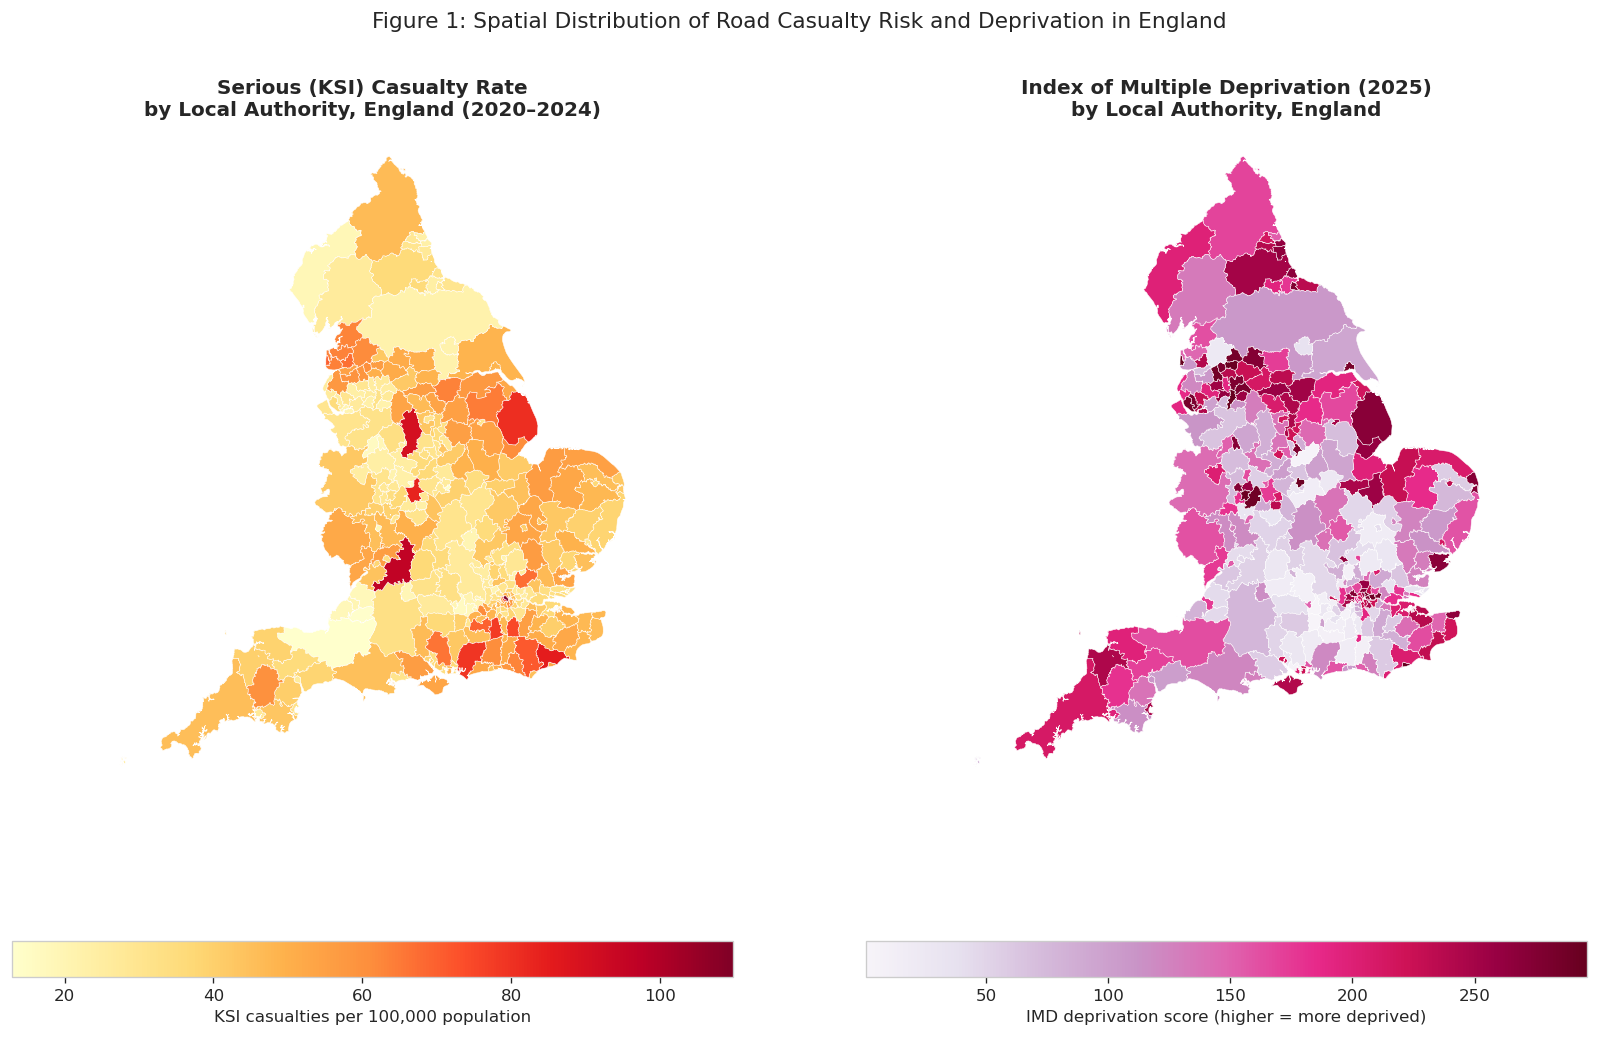

In [10]:
# 9. Choropleth maps: serious rate vs IMD score
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

gdf.plot(
    column='serious_rate', cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'KSI casualties per 100,000 population',
                 'orientation': 'horizontal', 'shrink': 0.7},
    missing_kwds={'color': 'lightgrey'}, edgecolor='white', linewidth=0.3, ax=axes[0]
)
axes[0].set_title('Serious (KSI) Casualty Rate\nby Local Authority, England (2020–2024)',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

gdf.plot(
    column='imd_score', cmap='PuRd', legend=True,
    legend_kwds={'label': 'IMD deprivation score (higher = more deprived)',
                 'orientation': 'horizontal', 'shrink': 0.7},
    missing_kwds={'color': 'lightgrey'}, edgecolor='white', linewidth=0.3, ax=axes[1]
)
axes[1].set_title('Index of Multiple Deprivation (2025)\nby Local Authority, England',
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Figure 1: Spatial Distribution of Road Casualty Risk and Deprivation in England',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# 10. Moran's I — spatial autocorrelation
from libpysal.weights import lag_spatial

gdf_valid = gdf.dropna(subset=['serious_rate']).copy()
gdf_valid = gdf_valid.to_crs(epsg=27700)

w = Queen.from_dataframe(gdf_valid, use_index=False)
w.transform = 'R'

y_moran = gdf_valid['serious_rate'].values
moran = Moran(y_moran, w)

print("=" * 45)
print("Moran's I — Spatial Autocorrelation Test")
print("=" * 45)
print(f"Moran's I statistic : {moran.I:.4f}")
print(f"Expected under CSR  : {moran.EI:.4f}")
print(f"p-value (sim.)      : {moran.p_sim:.4f}")
print(f"z-score             : {moran.z_sim:.4f}")
if moran.p_sim < 0.05:
    print("\nResult: Significant positive spatial autocorrelation detected.")
    print("High-risk LADs tend to cluster together geographically.")
else:
    print("\nResult: No significant spatial autocorrelation detected.")
print("Top 5 LADs by serious casualty rate:")
print(gdf_valid.nlargest(5, 'serious_rate')[['lad_name','serious_rate','population']].to_string())

('WARNING: ', 43, ' is an island (no neighbors)')
('WARNING: ', 49, ' is an island (no neighbors)')
Moran's I — Spatial Autocorrelation Test
Moran's I statistic : 0.3747
Expected under CSR  : -0.0034
p-value (sim.)      : 0.0010
z-score             : 9.6075

Result: Significant positive spatial autocorrelation detected.
High-risk LADs tend to cluster together geographically.
Top 5 LADs by serious casualty rate:
               lad_name  serious_rate  population
295         Westminster    109.811615    209996.0
102            Cotswold     96.442326     91661.0
71     Derbyshire Dales     90.304779     71757.0
87               Rother     84.882403     96133.0
203  North Warwickshire     83.436387     67117.0


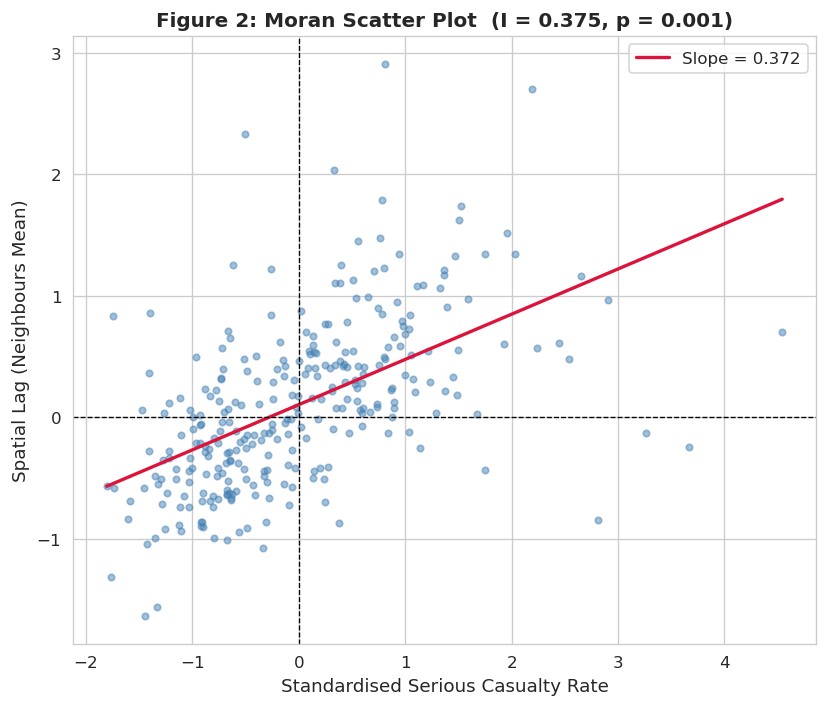

In [12]:
# 11. Moran scatter plot
y_std  = (y_moran - y_moran.mean()) / y_moran.std()
wy_vals = lag_spatial(w, y_std)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_std, wy_vals, alpha=0.5, s=15, color='steelblue')
m, b = np.polyfit(y_std, wy_vals, 1)
ax.plot(sorted(y_std), [m * xi + b for xi in sorted(y_std)],
        color='crimson', linewidth=2, label=f'Slope = {m:.3f}')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardised Serious Casualty Rate', fontsize=11)
ax.set_ylabel('Spatial Lag (Neighbours Mean)', fontsize=11)
ax.set_title(f"Figure 2: Moran Scatter Plot  (I = {moran.I:.3f}, p = {moran.p_sim:.3f})",
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Figure 1 reveals a pronounced north–south gradient, with rural LADs in the South West and East Midlands showing the highest rates. Notably, the highest-risk districts are not the most deprived — rural, low-deprivation LADs (Cotswold, Derbyshire Dales, North Warwickshire) appear in the top five, suggesting speed environment rather than deprivation alone drives extreme outcomes.

Moran's I yields **I = 0.375** (z = 9.61, p = 0.001), confirming significant positive spatial autocorrelation: high-risk LADs cluster geographically. The Moran Scatter Plot (Figure 2, slope = 0.372) confirms this, motivating spatially-aware analytical methods.

### Method 2: OLS Multiple Linear Regression

Regression sample: 295 LADs


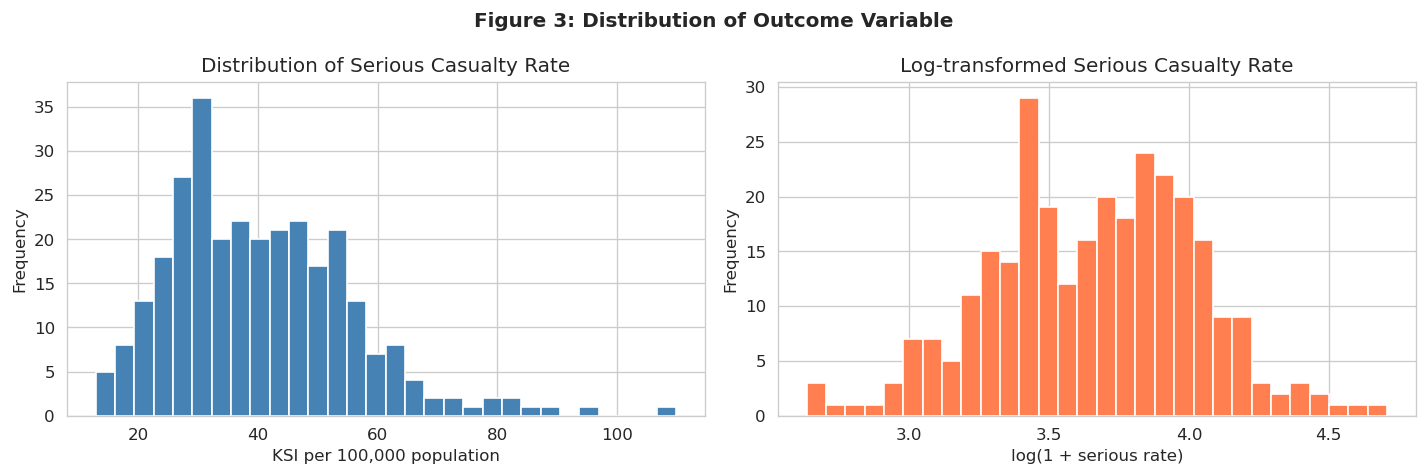

In [13]:
# 12. Prepare regression data + check distribution
reg_df = df[[
    'serious_rate', 'imd_score', 'is_urban', 'mean_speed_limit',
    'income_score', 'employment_score', 'education_score',
    'health_score', 'crime_score', 'housing_score', 'environment_score'
]].dropna()
print(f"Regression sample: {len(reg_df)} LADs")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(reg_df['serious_rate'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Serious Casualty Rate')
axes[0].set_xlabel('KSI per 100,000 population')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(reg_df['serious_rate']), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Log-transformed Serious Casualty Rate')
axes[1].set_xlabel('log(1 + serious rate)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Figure 3: Distribution of Outcome Variable', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

reg_df = reg_df.copy()
reg_df['log_serious_rate'] = np.log1p(reg_df['serious_rate'])

In [14]:
# 13. OLS Model 1: Core predictors
y_reg = reg_df['log_serious_rate']
X1 = sm.add_constant(reg_df[['imd_score', 'is_urban', 'mean_speed_limit']])
model1 = sm.OLS(y_reg, X1).fit()
print("MODEL 1: IMD score + Urban/Rural + Speed limit")
print(model1.summary())

MODEL 1: IMD score + Urban/Rural + Speed limit
                            OLS Regression Results                            
Dep. Variable:       log_serious_rate   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     15.36
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           2.66e-09
Time:                        22:26:56   Log-Likelihood:                -100.59
No. Observations:                 295   AIC:                             209.2
Df Residuals:                     291   BIC:                             223.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

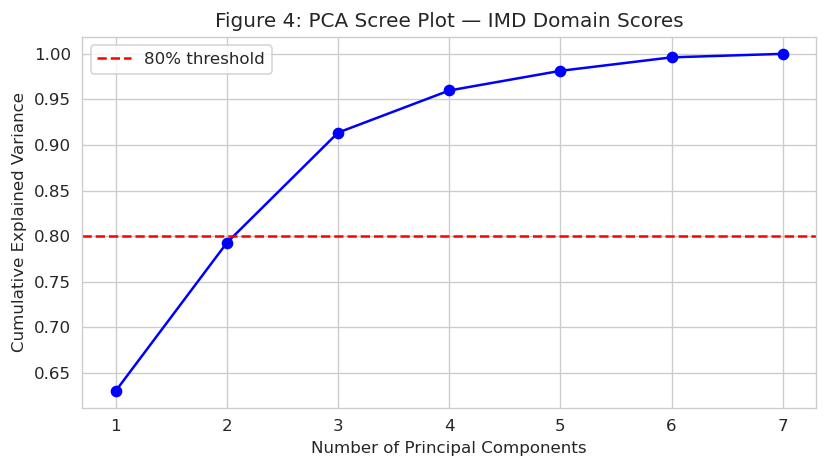

Explained variance ratio per component: [0.63  0.163 0.121 0.046 0.022 0.015 0.004]
PCA Loadings (higher absolute value = stronger association with that PC):
                     PC1    PC2    PC3
health_score       0.440 -0.206 -0.030
crime_score        0.411 -0.138  0.122
environment_score  0.228  0.402  0.810
housing_score      0.025  0.876 -0.353
income_score       0.457  0.091 -0.010
employment_score   0.463 -0.031 -0.062
education_score    0.401  0.015 -0.447
MODEL 2: PCA-reduced IMD domain scores + Urban/Rural + Speed limit
                            OLS Regression Results                            
Dep. Variable:       log_serious_rate   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     13.90
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           3.53e-12
Time:                        22:26:56   Log-Likelihood:             

In [15]:
# 14. OLS Model 2: PCA on IMD domain scores to address multicollinearity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select IMD domain scores for dimensionality reduction
domain_cols = ['health_score', 'crime_score', 'environment_score', 
               'housing_score', 'income_score', 'employment_score', 'education_score']

# Standardise domain scores before PCA
scaler_pca = StandardScaler()
domain_scaled = scaler_pca.fit_transform(reg_df[domain_cols])

# Fit PCA and plot cumulative explained variance (scree plot)
pca = PCA()
pca.fit(domain_scaled)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_.cumsum(), 'bo-')
ax.axhline(0.80, color='red', linestyle='--', label='80% threshold')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Figure 4: PCA Scree Plot — IMD Domain Scores')
ax.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio per component:", pca.explained_variance_ratio_.round(3))

# Retain components explaining >80% cumulative variance (adjust N_COMPONENTS based on scree plot)
N_COMPONENTS = 3
pca_final = PCA(n_components=N_COMPONENTS)
domain_pcs = pca_final.fit_transform(domain_scaled)

# Print PCA loadings to interpret what each PC represents
pc_cols = [f'PC{i+1}' for i in range(N_COMPONENTS)]
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=domain_cols,
    columns=pc_cols
).round(3)
print("PCA Loadings (higher absolute value = stronger association with that PC):")
print(loadings)

# Build regression dataframe combining PCs with structural variables
reg_pca_df = reg_df[['log_serious_rate', 'is_urban', 'mean_speed_limit']].copy()
for i, col in enumerate(pc_cols):
    reg_pca_df[col] = domain_pcs[:, i]
reg_pca_df = reg_pca_df.dropna()

# Fit OLS Model 2 using PCA components
X2 = sm.add_constant(reg_pca_df[['is_urban', 'mean_speed_limit'] + pc_cols])
model2 = sm.OLS(reg_pca_df['log_serious_rate'], X2).fit()
print("MODEL 2: PCA-reduced IMD domain scores + Urban/Rural + Speed limit")
print(model2.summary())

                 Model    R²  Adj. R²   AIC  Prob(F)
        Model 1 (Core) 0.137    0.128 209.2 2.66e-09
Model 2 (PCA-extended) 0.194    0.180 193.0 3.53e-12


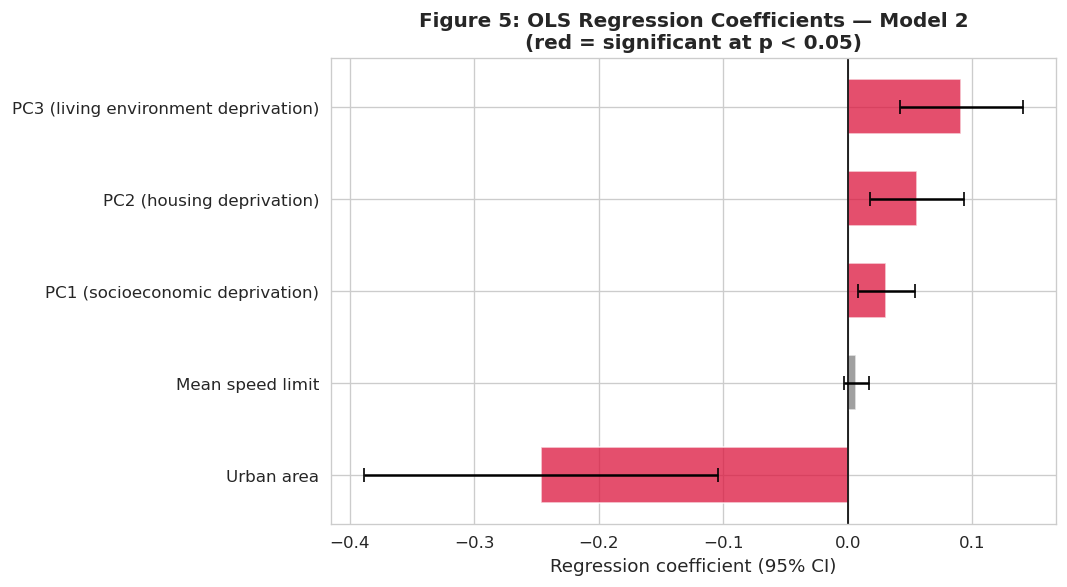

In [16]:
# 15. Model comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 (Core)', 'Model 2 (PCA-extended)'],
    'R²':       [round(model1.rsquared,     3), round(model2.rsquared,     3)],
    'Adj. R²':  [round(model1.rsquared_adj, 3), round(model2.rsquared_adj, 3)],
    'AIC':      [round(model1.aic, 1),          round(model2.aic, 1)],
    'Prob(F)':  [f'{model1.f_pvalue:.2e}',      f'{model2.f_pvalue:.2e}']
})
print(comparison.to_string(index=False))

# Coefficient plot for Model 2
coefs = model2.params.drop('const')
cis   = model2.conf_int().drop('const')
pvals = model2.pvalues.drop('const')

# Update PC labels after inspecting loadings output above
labels = {
    'is_urban':         'Urban area',
    'mean_speed_limit': 'Mean speed limit',
    'PC1': 'PC1 (socioeconomic deprivation)',
    'PC2': 'PC2 (housing deprivation)',
    'PC3': 'PC3 (living environment deprivation)',
}

colors = ['crimson' if pvals[v] < 0.05 else 'grey' for v in coefs.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(coefs)), coefs.values,
        xerr=[coefs.values - cis[0].values, cis[1].values - coefs.values],
        color=colors, alpha=0.75, height=0.6, capsize=4)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels([labels.get(v, v) for v in coefs.index], fontsize=10)
ax.set_xlabel('Regression coefficient (95% CI)', fontsize=11)
ax.set_title('Figure 5: OLS Regression Coefficients — Model 2\n(red = significant at p < 0.05)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Figure 3 shows the serious casualty rate is right-skewed; log(1 + rate) transformation is applied in all regression models.

**Model 1** explains **R² = 0.137** (p < 0.001). IMD score is positive and significant (β = 0.0006, p = 0.017); urban indicator is strongly negative (β = −0.332, p < 0.001). Speed limit is non-significant (p = 0.521).

**Model 2** replaces IMD score with three PCA components (explaining >80% of domain variance, Figure 4), achieving **R² = 0.194** (AIC: 209.2 → 193.0). All three components are significant (p < 0.01); urban area remains strongly negative (β = −0.246, p = 0.001).

### Method 3: Random Forest Regression + SHAP

In [17]:
# 16. Prepare features and train Random Forest
feature_cols = [
    'imd_score', 'is_urban', 'mean_speed_limit',
    'income_score', 'employment_score', 'education_score',
    'health_score', 'crime_score', 'housing_score', 'environment_score'
]
nice_labels = {
    'imd_score': 'IMD (overall)', 'is_urban': 'Urban area',
    'mean_speed_limit': 'Speed limit', 'income_score': 'Income deprivation',
    'employment_score': 'Employment deprivation', 'education_score': 'Education deprivation',
    'health_score': 'Health deprivation', 'crime_score': 'Crime deprivation',
    'housing_score': 'Housing & services', 'environment_score': 'Living environment'
}

rf_df = df[feature_cols + ['serious_rate']].dropna()
X = rf_df[feature_cols]
y_rf = rf_df['serious_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y_rf, test_size=0.25, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

rf = RandomForestRegressor(n_estimators=500, max_depth=4,
                            min_samples_leaf=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred   = rf.predict(X_test)
r2       = r2_score(y_test, y_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
cv_scores = cross_val_score(rf, X, y_rf, cv=5, scoring='r2')

print(f"Test R²             : {r2:.3f}")
print(f"Test RMSE           : {rmse:.2f} per 100,000")
print(f"5-fold CV R² (mean) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Train: 221 | Test: 74
Test R²             : 0.180
Test RMSE           : 11.73 per 100,000
5-fold CV R² (mean) : -0.085 ± 0.215


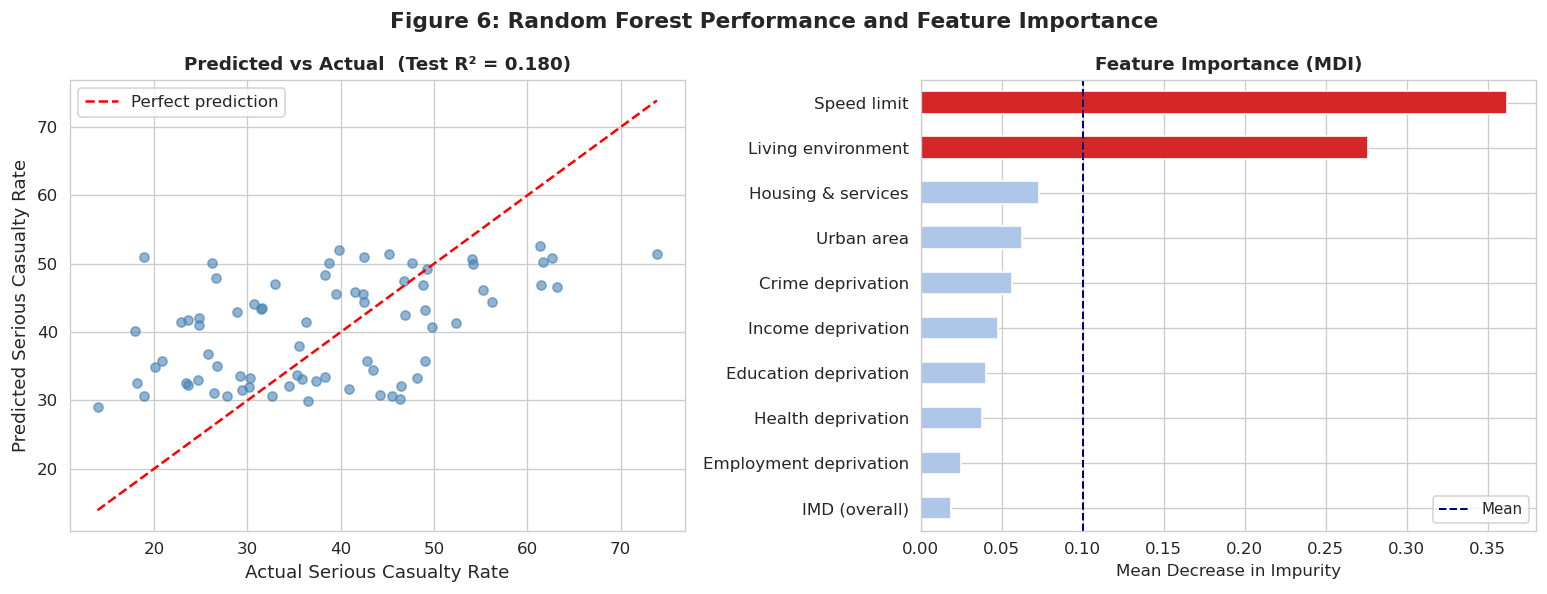

In [18]:
# 17. Predicted vs Actual + Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', s=30)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Serious Casualty Rate', fontsize=11)
axes[0].set_ylabel('Predicted Serious Casualty Rate', fontsize=11)
axes[0].set_title(f'Predicted vs Actual  (Test R² = {r2:.3f})', fontsize=11, fontweight='bold')
axes[0].legend()

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.index = [nice_labels.get(i, i) for i in importances.index]
colors_fi = ['#d62728' if v > importances.mean() else '#aec7e8' for v in importances.values]
importances.plot(kind='barh', ax=axes[1], color=colors_fi, edgecolor='white')
axes[1].axvline(importances.mean(), color='navy', linestyle='--', linewidth=1.2, label='Mean')
axes[1].set_title('Feature Importance (MDI)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Impurity', fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle('Figure 6: Random Forest Performance and Feature Importance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

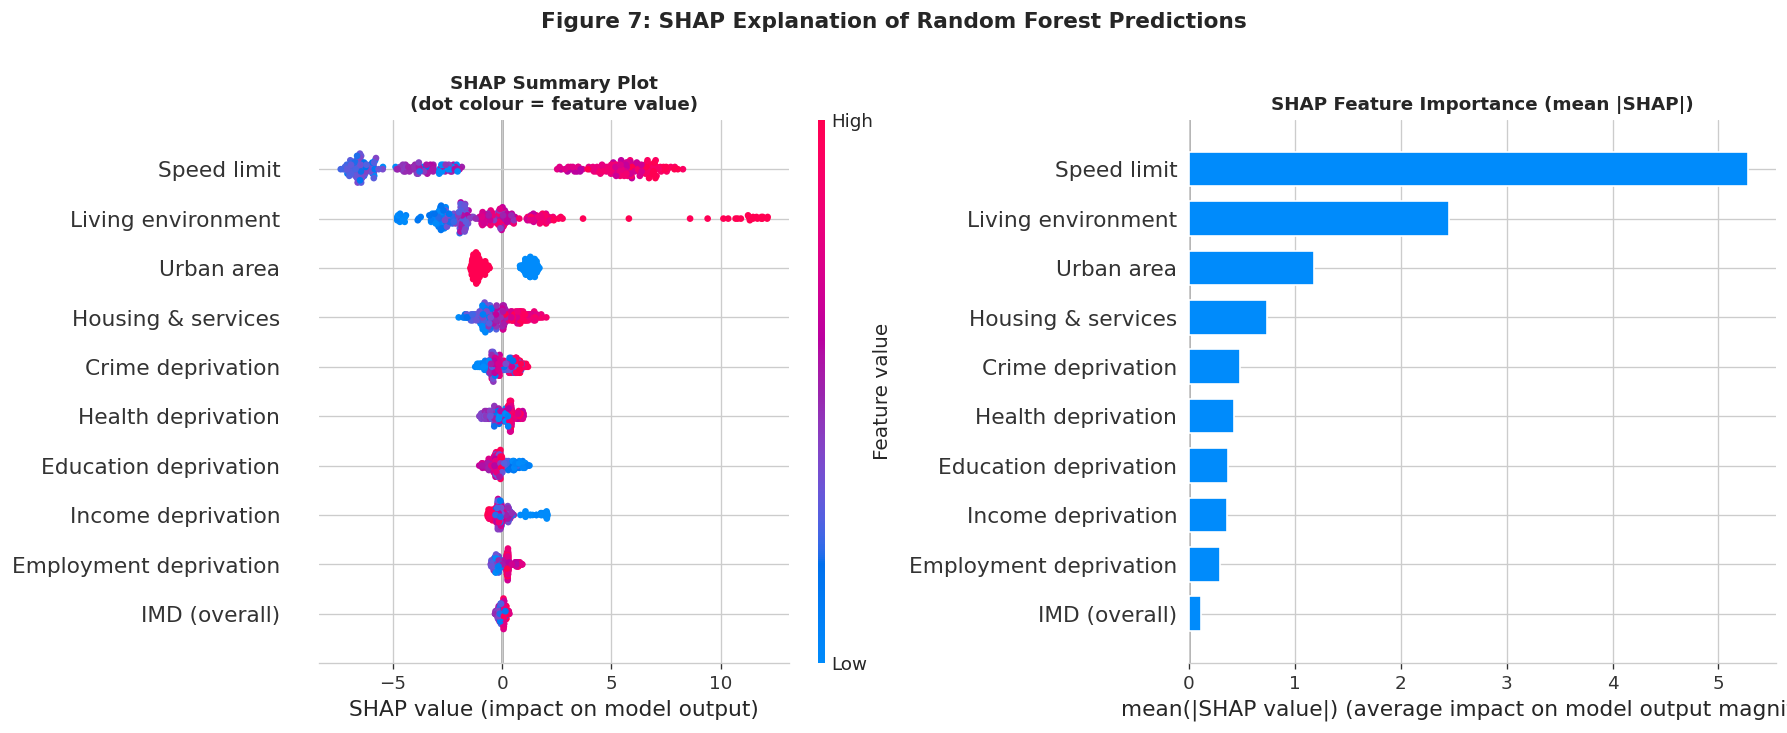

In [19]:
# 18. SHAP values
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plt.sca(axes[0])
shap.summary_plot(
    shap_values, X,
    feature_names=[nice_labels.get(c, c) for c in feature_cols],
    show=False, plot_size=None
)
axes[0].set_title('SHAP Summary Plot\n(dot colour = feature value)',
                  fontsize=11, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(
    shap_values, X,
    feature_names=[nice_labels.get(c, c) for c in feature_cols],
    plot_type='bar', show=False, plot_size=None
)
axes[1].set_title('SHAP Feature Importance (mean |SHAP|)',
                  fontsize=11, fontweight='bold')

plt.suptitle('Figure 7: SHAP Explanation of Random Forest Predictions',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** The Random Forest achieves a test **R² = 0.180**, RMSE = 11.73 per 100,000. However, the negative cross-validated R² (−0.085 ± 0.215) reveals model instability due to high variance and small sample size (n = 295), suggesting LAD-level accident rates are heavily influenced by unobserved factors and potential ecological fallacy.

Nevertheless, SHAP values (Figure 7) and MDI feature importance (Figure 6) consistently identify **speed limit** and **living environment deprivation** as the primary predictors — aligning with OLS findings and reinforcing the robustness of these key drivers across methods.

### Method 4: K-Means Clustering — Spatial Risk Profiles

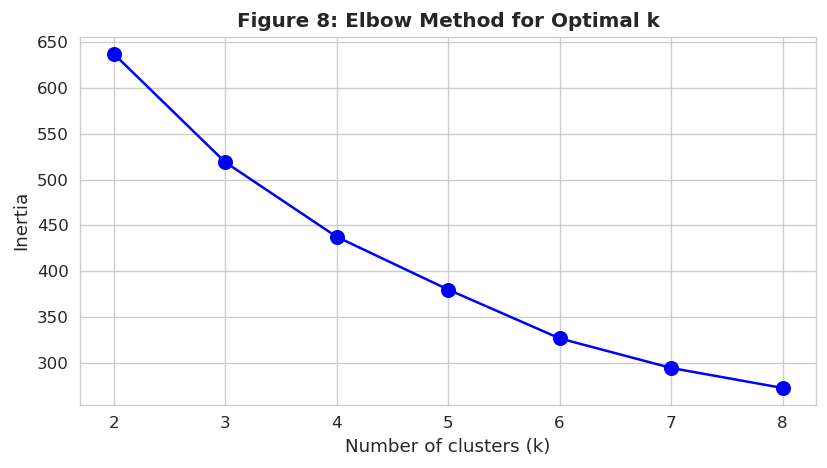

In [20]:
# 19. Elbow method to find optimal k
cluster_features = ['serious_rate', 'imd_score', 'pct_urban', 'mean_speed_limit']
cluster_df = df[cluster_features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, 'bo-', markersize=8)
ax.set_xlabel('Number of clusters (k)', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)
ax.set_title('Figure 8: Elbow Method for Optimal k', fontsize=12, fontweight='bold')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

In [21]:
# 20. Fit K-Means (adjust K_OPTIMAL after reviewing elbow plot)
K_OPTIMAL = 4  # ← adjust based on elbow plot

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

# Merge clusters back
df_clustered = df.copy().loc[cluster_df.index]
df_clustered['cluster'] = cluster_df['cluster'].values

# Profile table
profile = df_clustered.groupby('cluster')[cluster_features].mean().round(2)
profile['n_lads'] = df_clustered.groupby('cluster').size()
print("Cluster Profiles (review these to write accurate labels below)")
print(profile.to_string())

Cluster Profiles (review these to write accurate labels below)
         serious_rate  imd_score  pct_urban  mean_speed_limit  n_lads
cluster                                                              
0               29.29      98.89      74.53             35.26      63
1               40.69      72.85      29.40             46.51      87
2               57.27     179.38      32.08             44.58      52
3               38.42     236.88      86.86             31.85      93


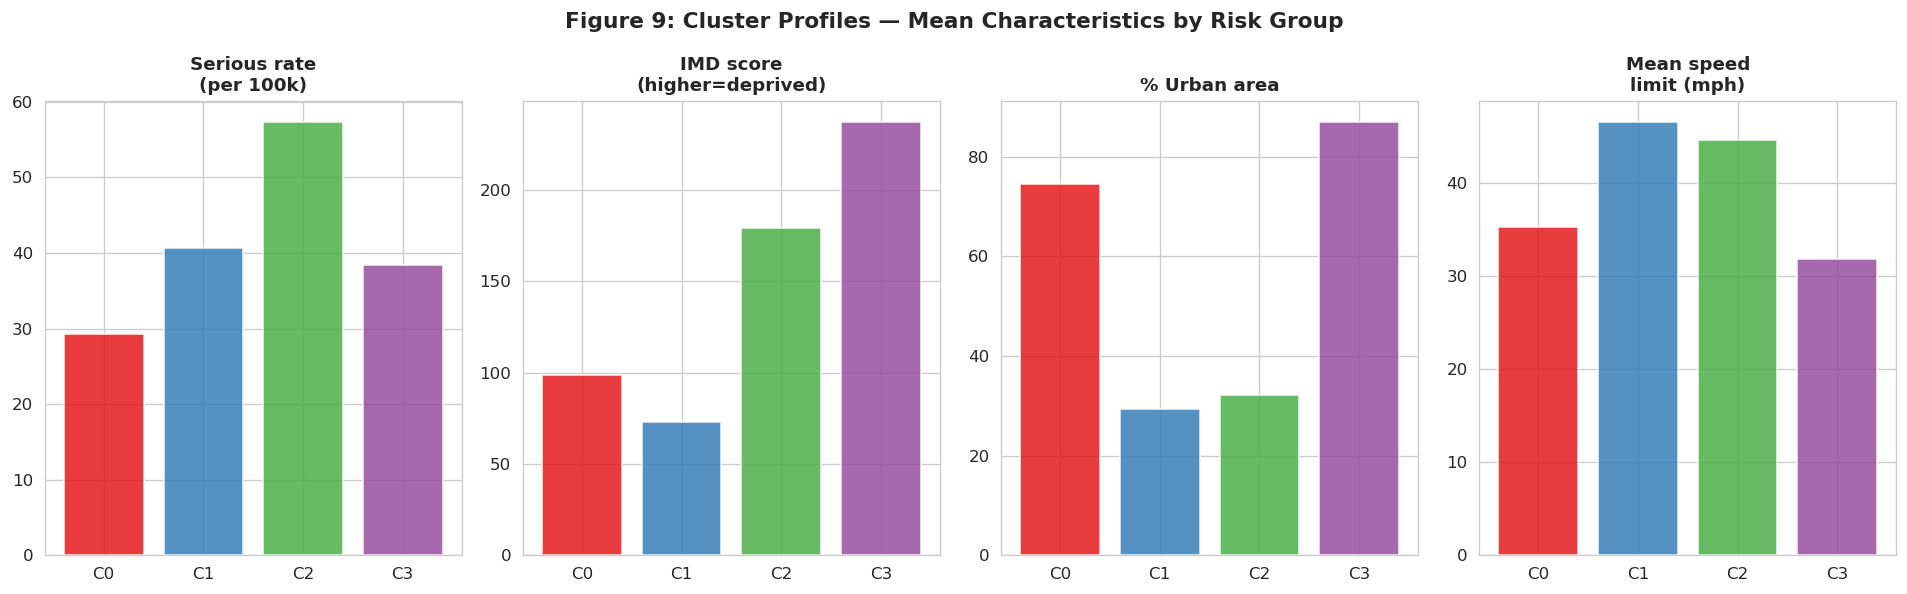

In [22]:
# 21. Label clusters + profile bar chart
# !! Update these labels based on the profile table printed above !!
CLUSTER_LABELS = {
    0: 'Cluster A: Residential Urban, Low Deprivation & Risk',
    1: 'Cluster B: Rural Transition, Low Deprivation & Moderate Risk',
    2: 'Cluster C: Rural High-Speed, Moderate Deprivation & High Risk',
    3: 'Cluster D: Deprived Urban, High Density & Moderate Risk'
}
df_clustered['cluster_label'] = df_clustered['cluster'].map(CLUSTER_LABELS)
palette_map = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a', 3: '#984ea3'}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics = ['serious_rate', 'imd_score', 'pct_urban', 'mean_speed_limit']
titles  = ['Serious rate\n(per 100k)', 'IMD score\n(higher=deprived)',
            '% Urban area', 'Mean speed\nlimit (mph)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals = [profile.loc[c, metric] for c in range(K_OPTIMAL)]
    axes[i].bar(range(K_OPTIMAL), vals,
                color=[palette_map[c] for c in range(K_OPTIMAL)],
                edgecolor='white', alpha=0.85)
    axes[i].set_xticks(range(K_OPTIMAL))
    axes[i].set_xticklabels([f'C{c}' for c in range(K_OPTIMAL)], fontsize=10)
    axes[i].set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Figure 9: Cluster Profiles — Mean Characteristics by Risk Group',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

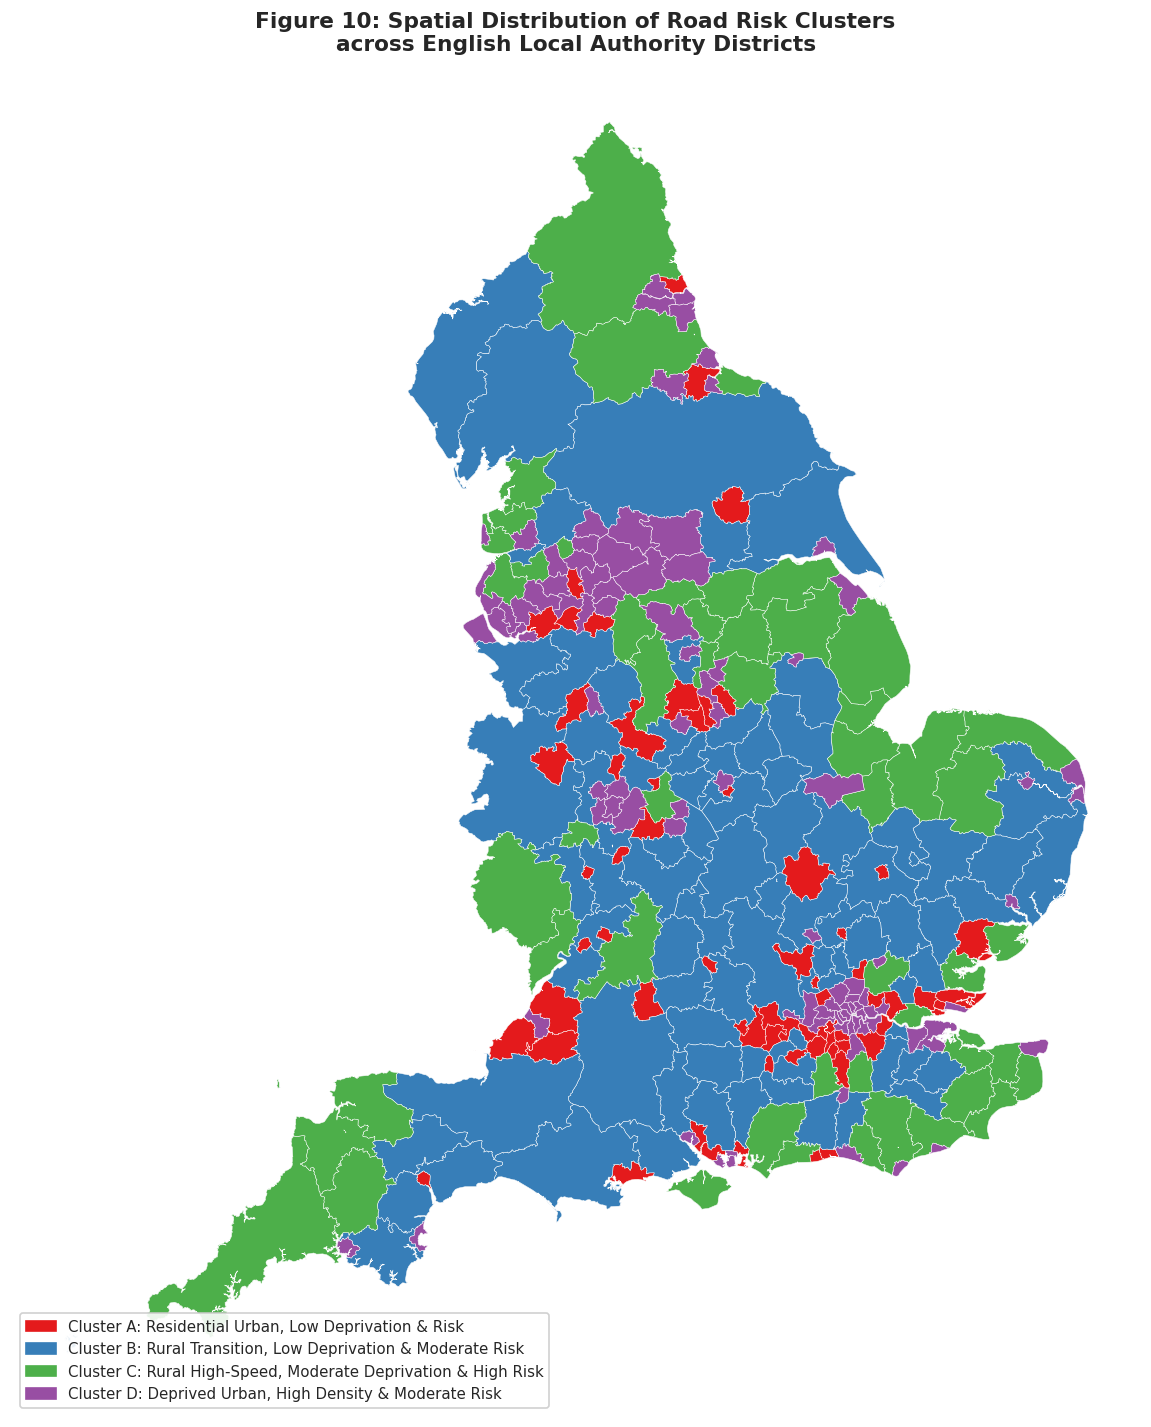

In [23]:
# 22. Map clusters spatially
gdf_cl = gdf_lad.merge(
    df_clustered[['lad_code', 'cluster', 'cluster_label']], on='lad_code', how='left'
)

fig, ax = plt.subplots(figsize=(10, 12))
gdf_cl.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)

for cl, color in palette_map.items():
    subset = gdf_cl[gdf_cl['cluster'] == cl]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.3)

legend_patches = [
    mpatches.Patch(color=c, label=CLUSTER_LABELS[k]) for k, c in palette_map.items()
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('Figure 10: Spatial Distribution of Road Risk Clusters\nacross English Local Authority Districts',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

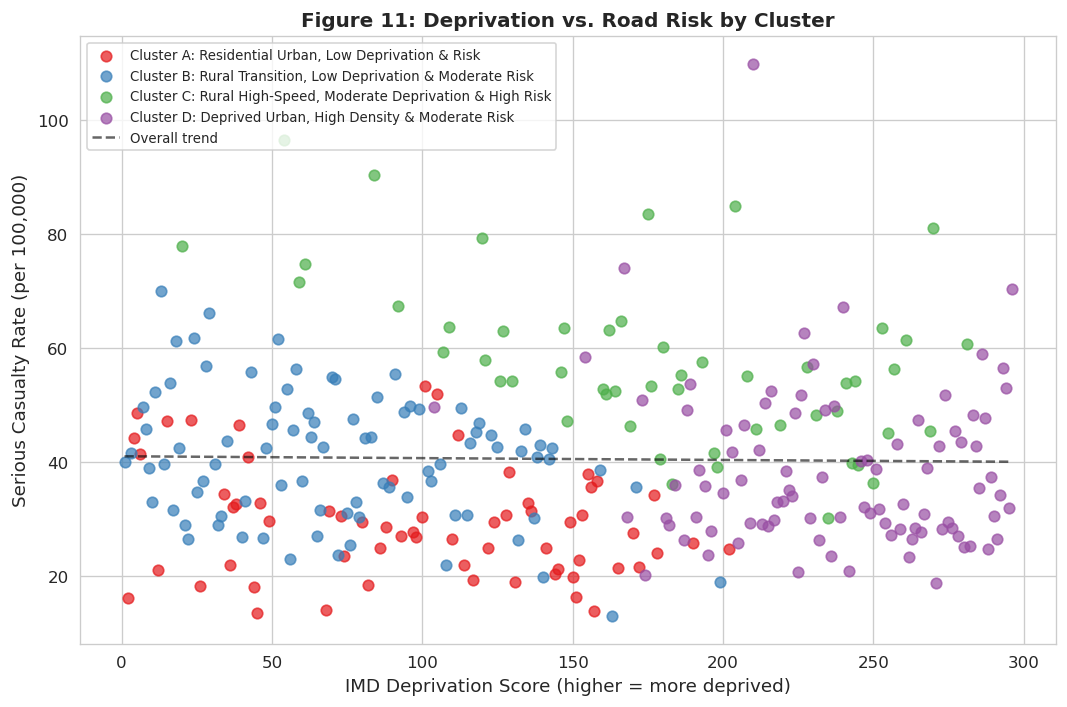

In [24]:
# 23. Scatter: risk vs deprivation, coloured by cluster
fig, ax = plt.subplots(figsize=(9, 6))
for cl, color in palette_map.items():
    subset = df_clustered[df_clustered['cluster'] == cl]
    ax.scatter(subset['imd_score'], subset['serious_rate'],
               color=color, alpha=0.7, s=40, label=CLUSTER_LABELS[cl])

z = np.polyfit(df_clustered['imd_score'].dropna(),
               df_clustered['serious_rate'].dropna(), 1)
xs = np.linspace(df_clustered['imd_score'].min(), df_clustered['imd_score'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=1.5, alpha=0.6, label='Overall trend')
ax.set_xlabel('IMD Deprivation Score (higher = more deprived)', fontsize=11)
ax.set_ylabel('Serious Casualty Rate (per 100,000)', fontsize=11)
ax.set_title('Figure 11: Deprivation vs. Road Risk by Cluster', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation:** The elbow plot (Figure 8) indicates k = 4 as optimal. **Cluster A** (n = 63, urban, low deprivation, rate = 29.3) represents prosperous LADs concentrated in London and the South East. **Cluster B** (n = 87, mixed rural–urban, rate = 40.7) is the modal English LAD. **Cluster C** (n = 52, rural, moderate deprivation, rate = 57.3) is the highest-risk group. **Cluster D** (n = 93, highly deprived urban, rate = 38.4) shows that lower speeds partially offset social risk.

Figure 11 reveals a non-monotonic relationship: Cluster C records the highest rates across a wide deprivation range, while Cluster D concentrates at lower rates — confirming urbanicity moderates risk as much as deprivation.

In [25]:
# Runtime
elapsed = time.time() - start_time
print(f'Total runtime: {elapsed/60:.1f} minutes ({elapsed:.0f} seconds)')

Total runtime: 2.4 minutes (145 seconds)


## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study examined whether road accident risk is socially and spatially unequal across English LADs using STATS19 data (2020–2024) linked to deprivation and population datasets. Serious casualty risk is **significantly spatially clustered** (Moran's I = 0.375, p = 0.001), concentrated in rural areas. **Social deprivation is positively and independently associated with higher rates** (all PCA components p < 0.01), but the urban–rural dimension is equally important: urban LADs have systematically lower rates, suggesting road design and speed management partially counteract social disadvantage.

The random forest highlights **speed limit** as the most important predictor under non-linear effects. K-means clustering reveals that the most dangerous LADs (Cluster C) are rural and moderately deprived — a risk profile mapping onto neither the deprivation nor the urban safety agenda — suggesting geographically tailored interventions are needed.

Limitations include ecological fallacy at LAD level, absent traffic volume data, and low explained variance (max R² = 19.4%). Cluster C districts should be a priority for targeted road safety investment and speed reduction measures.

## References

[[ go back to the top ]](#Table-of-contents)

Anselin, L. (1995). Local indicators of spatial association—LISA. *Geographical Analysis*, 27(2), 93–115. https://doi.org/10.1111/j.1538-4632.1995.tb00338.x

Department for Transport. (2023). *Reported road casualties Great Britain: 2022 annual report*. UK Government. https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-annual-report-2022

Graham, D. J., & Glaister, S. (2003). Spatial variation in road pedestrian casualties: The role of urban scale, density and land-use mix. *Urban Studies*, 40(8), 1591–1607. https://doi.org/10.1080/0042098032000094441

Lyons, R. A., Jones, S. J., Deacon, T., & Heaven, M. (2008). Socioeconomic variation in injury in children and older people: A population based study. *Injury Prevention*, 9(1), 33–37. https://doi.org/10.1136/ip.9.1.33

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*, 30, 4765–4774. https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html

Ministry of Housing, Communities & Local Government (MHCLG). (2025). *English indices of deprivation 2025*. Open Data Communities. https://opendatacommunities.org/resource?uri=http%3A%2F%2Fopendatacommunities.org%2Fdata%2Fsocietal-wellbeing%2Fimd%2Findices

Office for National Statistics (ONS). (2024). *Population estimates for UK, England, Wales, Scotland and Northern Ireland*. Nomis. https://www.nomisweb.co.uk/

Quddus, M. A. (2008). Modelling area-wide count outcomes with spatial correlation and heterogeneity: An analysis of London crash data. *Accident Analysis & Prevention*, 40(4), 1486–1497. https://doi.org/10.1016/j.aap.2008.03.009

UK Department for Transport. (2024). *STATS19 road safety data 2020–2024*. data.gov.uk. https://www.data.gov.uk/dataset/cb7ae6f0-4be6-4935-9277-47e5ce24a11f/road-accidents-safety-data